In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
baseline_path = r"C:\Users\Mark.DESKTOP-UFHIN6T\OneDrive - London School of Economics\Uganda\Macro\DIGNAD\DIGNAD_FRM_RP100_baseline.csv"
adapted_path = r"C:\Users\Mark.DESKTOP-UFHIN6T\OneDrive - London School of Economics\Uganda\Macro\DIGNAD\DIGNAD_FRM_RP100_adapted.csv"
# baseline_path = r"C:\Users\Mark.DESKTOP-UFHIN6T\OneDrive - London School of Economics\Uganda\Macro\DIGNAD\DIGNAD_stylized_5pct.csv"
# adapted_path = r"C:\Users\Mark.DESKTOP-UFHIN6T\OneDrive - London School of Economics\Uganda\Macro\DIGNAD\DIGNAD_stylized_10pct.csv"
base = pd.read_csv(baseline_path)
adpt = pd.read_csv(adapted_path)

In [38]:
base = base.rename(columns={'Years':'year'})
adpt = adpt.rename(columns={'Years':'year'})
base["year"] = pd.to_numeric(base["year"], errors="coerce")
adpt["year"] = pd.to_numeric(adpt["year"], errors="coerce")

In [39]:
# What columns do we want to plot
vars_to_plot = [
    'Public Infrastructure Inv. (\% of GDP)',
    'Real GDP (\% dev. from SS)',
    # 'Private Inv. Growth (\% dev. from SS)',
    'Domestic Public Debt (\% of GDP)',
    'Concessional Debt (\% of GDP)',
    'Total Public Debt (\% of GDP)',
    'Fiscal Deficit (\% of GDP)',
    'Real GDP Growth (\% YoY)',
    'Tradable Output Growth (\% dev. from SS)',
    'Non-Tradable Output Growth (\% dev. from SS)',
    'Current Account Deficit (\% of GDP)',
    'Real Exchange Rate (dep. -, \% dev. from SS)',
    'Real Interest Rate (\%)'
]

In [40]:
# Merge baseline and adapted for easy plotting
df = pd.merge(
    base[["year"] + vars_to_plot],
    adpt[["year"] + vars_to_plot],
    on="year",
    how="inner",
    suffixes=("_baseline", "_adapted")
).sort_values("year")

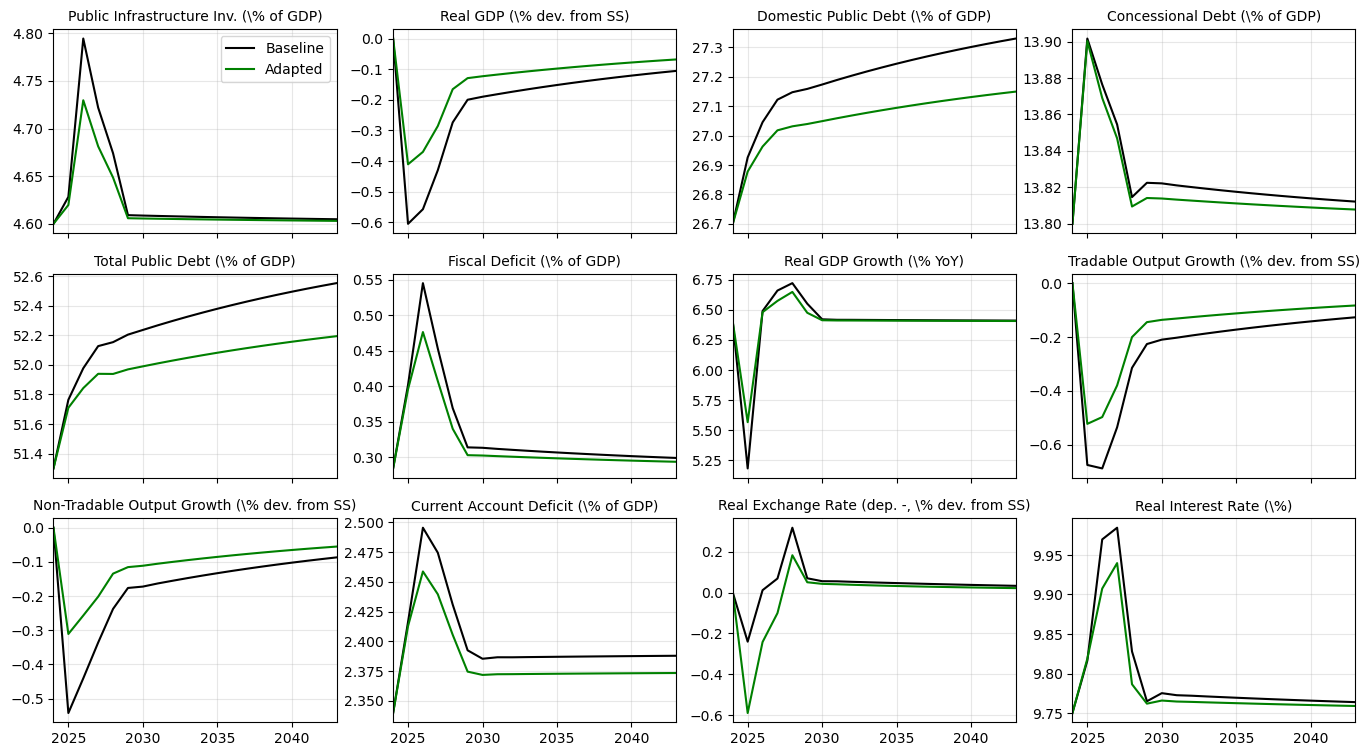

In [41]:
# Plot on grid
n = len(vars_to_plot)
ncols = 4                      # tweak: 3, 4, 5...
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.2*ncols, 3.0*nrows), sharex=True)
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    ax.plot(df["year"], df[f"{var}_baseline"], label="Baseline", color='k')
    ax.plot(df["year"], df[f"{var}_adapted"],  label="Adapted", color='g')
    # ax.plot(df["year"], df[f"{var}_baseline"], label="5% Shock", color='orange')
    # ax.plot(df["year"], df[f"{var}_adapted"],  label="10% Shock", color='red')
    ax.set_title(var, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(df["year"].min(), df["year"].max())
    if i == 0:
        ax.legend()

# remove empty panels
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper center", ncols=2, frameon=True)